In [37]:
from pdf2image import convert_from_path
import pytesseract
import matplotlib.pyplot as plt
import numpy as np
import cv2
import re
from PIL.PpmImagePlugin import PpmImageFile 
from typing import Dict 

POPPLER_PATH = r"C:\Users\Moaz\Downloads\Release-24.08.0-0\poppler-24.08.0\Library\bin"
TESSERACT_ENGINE_PATH = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
pytesseract.pytesseract.tesseract_cmd = TESSERACT_ENGINE_PATH

In [38]:
DOC_PATH = r"M:\SportsInjuryRehab\physiotherapy\models\text_extraction\medical_reports\report.pdf"

In [39]:
pages = convert_from_path(DOC_PATH, poppler_path=POPPLER_PATH)
pages

[<PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=1653x2339>]

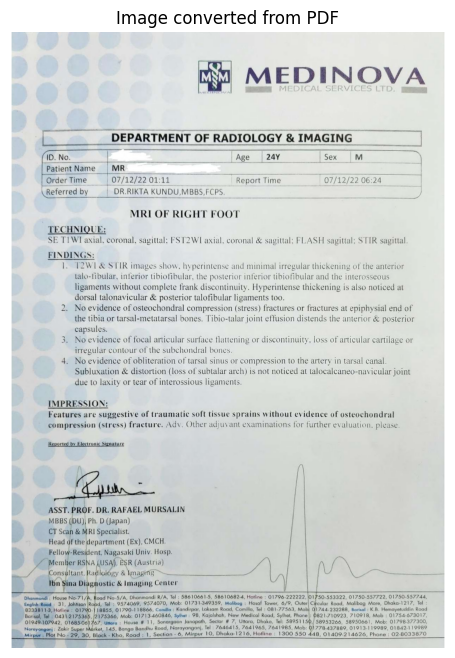

In [40]:
plt.figure(figsize=(6,8))
plt.imshow(pages[0])
plt.axis(False)
plt.title("Image converted from PDF")
plt.show()

In [41]:
text = pytesseract.image_to_string(pages[0], lang="eng")
print(text)



MEDINOVA

—_— Se OF RADIOLOGY & IMAGING

ID. No. | Age | 24¥ | Sex | M ; 7
Patient Name han : 7 |
OrderTime | 07/12/22 01:11 | _ Report Time 07/12/22 06:24 |
\Referred by | DR.RIKTA KUNDU,MBBS, FCPS. ms,

MRI OF RIGHT FOOT
TECHNIQUE:

SE T1WI axial, coronal, sagittal: FST2WI axial. coronal & sagittal: FLASH sagittal: STIR sagittal.
FINDINGS:

1, T2WIL& STIR images show. hyperintense and minimal irregular thickening of the anterior
talo-tibular, inferior tibiofibular, the posterior inferior tibiofibular and the interosseous
ligaments without complete frank discontinuity. Hyperintense thickening is also noticed at
dorsal talonavicular & posterior talofibular ligaments too.

No evidence of osteochondral compression (stress) fractures or fractures at epiphysial end of
the tibia or tarsal-metatarsal bones. Tibio-talar joint effusion distends the anterior & posterior
capsules.

No evidence of focal articular surface flattening or discontinuity. loss of articular cartilage or
irregular contou

In [42]:

def preprocess_image(img: PpmImageFile) -> np.ndarray:
    gray = cv2.cvtColor(np.array(img), cv2.COLOR_BGR2GRAY) 
    resized = cv2.resize(gray, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR) 
    processed_image = cv2.adaptiveThreshold(
        resized, 
        255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        
        cv2.THRESH_BINARY, 
        63, 
        12  
    )
    return processed_image

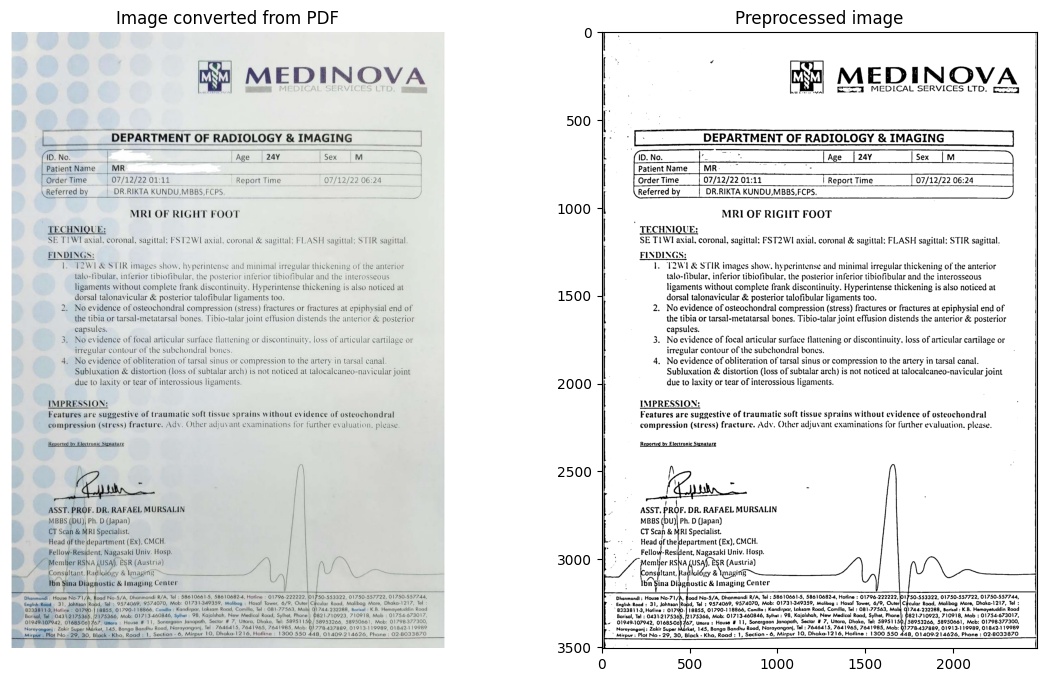

In [43]:
img = preprocess_image(pages[0])
plt.figure(figsize=(14,8))
plt.subplot(1, 2, 1)
plt.imshow(pages[0])
plt.axis(False)
plt.title("Image converted from PDF")
plt.subplot(1, 2, 2)
plt.imshow(img, cmap="gray")
plt.axis()
plt.title("Preprocessed image")
plt.show()

In [44]:

text_1 = pytesseract.image_to_string(img, lang="eng")
print(text_1)

MEDINOVA

| : | al Ey MEDICAL SERVICES LTD. roy
|

[PatientName [MR
07/12/22 01:11 Report Time 07/12/22 06:24

Referred by DR.RIKTA KUNDU,MBBS,FCPS.

MRI OF RIGHT FOOT

TECHNIQUE:
SE T1WI axial. coronal, sagittal: FST2WI axial. coronal & sagittal: FLASH sagittal: STIR sagittal.
FINDINGS:

1. T2WL& STIR images show, hyperintense and minimal irregular thickening of the anterior
talo-fibular, inferior tbiofibular, the posterior inferior tibiofibular and the interosseous
ligaments without complete frank discontinuity. Hyperintense thickening is also noticed at
dorsal talonavicular & posterior talofibular ligaments too.

2. No evidence of osteochondral compression (stress) fractures or fractures at epiphysial end of
the tibia or tarsal-metatarsal bones. Tibio-talar joint effusion distends the anterior & posterior
capsules.

No evidence of focal articular surface flattening or discontinuity. loss of articular cartilage or

irregular contour of the subchondral bones.

4. No evidence of oblite

In [45]:
import re
from typing import Dict

def parse(text: str) -> Dict:
    return {
        "patient_name": get_field("patient_name", text),
        "patient_age": get_field("patient_age", text),
        "patient_sex": get_field("patient_sex", text),
        "technique": get_field("technique", text),
        "findings": get_field("findings", text),
        "impression": get_field("impression", text),
        "referred_by": get_field("referred_by", text),
        "injury_location": get_field("injury_location", text),
        "injury_severity": get_field("injury_severity", text),
        "imaging_results": get_field("imaging_results", text),
        "diagnosis": get_field("diagnosis", text),
        "recommendations": get_field("recommendations", text),
        "date_of_exam": get_field("date_of_exam", text),
        "physician_name": get_field("physician_name", text),
        "history": get_field("history", text),
        "clinical_exam": get_field("clinical_exam", text),
        "procedure": get_field("procedure", text),
        "comparison": get_field("comparison", text),
        "conclusion": get_field("conclusion", text),
        "clinical_information": get_field("clinical_information", text),
        "observations": get_field("observations", text),  
    }

def get_field(field_name: str, text: str) -> str:
    pattern_dict = {
        "patient_name": {"pattern": r"(?:PatientName|Patient Name)\s*(?:\[|:)\s*(\w+)", "flags": re.IGNORECASE},
        "patient_age": {"pattern": r"Age\s*:\s*(\d+Y?)", "flags": re.IGNORECASE},
        "patient_sex": {"pattern": r"Sex\s*:\s*(\w+)", "flags": re.IGNORECASE},
        "technique": {"pattern": r"(?:TECHNIQUE:|TECHNIQUE|Protocol):\s*(.*?)(?=\s*(?:OBSERVATION:|FINDINGS:|$))", "flags": re.DOTALL | re.IGNORECASE},
        "findings": {"pattern": r"(?:FINDINGS:|Findings:)\s*(.*?)(?=\s*(?:IMPRESSION:|Impression:|$))", "flags": re.DOTALL | re.IGNORECASE},
        "impression": {"pattern": r"(?:IMPRESSION:|Impression:)\s*(.*?)(?=\s*(?:Adv\.|$))", "flags": re.DOTALL | re.IGNORECASE},
        "referred_by": {"pattern": r"(?:Referred by|Referring Physician)\s*(?::|=)?\s*([^\.]+?)(?=\.|$)", "flags": re.IGNORECASE},
        "injury_location": {"pattern": r"(?:Injury Location|Site of pain)\s*(?::|=)?\s*([^\.]+?)(?=\.|$)", "flags": re.IGNORECASE},
        "injury_severity": {"pattern": r"Injury Severity\s*(?::|=)?\s*([^\.]+?)(?=\.|$)", "flags": re.IGNORECASE},
        "imaging_results": {"pattern": r"Imaging Results\s*(?::|=)?\s*([^\.]+?)(?=\.|$)", "flags": re.DOTALL | re.IGNORECASE},
        "diagnosis": {"pattern": r"Diagnosis\s*(?::|=)?\s*([^\.]+?)(?=\.|$)", "flags": re.IGNORECASE},
        "recommendations": {"pattern": r"(?:Adv\.|Recommendations)\s*(.*?)(?=\s*(?:Reported by|$))", "flags": re.DOTALL | re.IGNORECASE},
        "date_of_exam": {"pattern": r"(?:Report Time|Date|Exam Date)\s*(?::|=)?\s*([\d/]+(?:\s*[\d:]+)?)", "flags": re.IGNORECASE},
        "physician_name": {"pattern": r"(?:DR\.|Doctor|Physician|Radiologist)\s*([^,\n]+)", "flags": re.IGNORECASE},
        "history": {"pattern": r"History\s*(?::|=)?\s*([^\.]+?)(?=\.|$)", "flags": re.DOTALL | re.IGNORECASE},
        "clinical_exam": {"pattern": r"Clinical Exam\s*(?::|=)?\s*([^\.]+?)(?=\.|$)", "flags": re.DOTALL | re.IGNORECASE},
        "procedure": {"pattern": r"(?:MRI of|MRI OF|MRI -)\s*(.*?)(?=\s*\d|\n|Clinical|$)", "flags": re.IGNORECASE},
        "comparison": {"pattern": r"Comparison\s*(?::|=)?\s*([^\.]+?)(?=\.|$)", "flags": re.DOTALL | re.IGNORECASE},
        "conclusion": {"pattern": r"Conclusion\s*(?::|=)?\s*([^\.]+?)(?=\.|$)", "flags": re.DOTALL | re.IGNORECASE},
        "clinical_information": {"pattern": r"(?:Clinical Information|History|Clinical)\s*(?::|=)?\s*([^\.]+?)(?=\.|Findings:|$)", "flags": re.DOTALL | re.IGNORECASE},
        "observations": {"pattern": r"(?:OBSERVATION:|Observations:)\s*(.*?)(?=\s*(?:IMPRESSION:|Conclusion:|$))", "flags": re.DOTALL | re.IGNORECASE},
    }

    pattern_object = pattern_dict.get(field_name)
    if pattern_object:
        matches = re.findall(pattern_object["pattern"], text, flags=pattern_object["flags"])
        if len(matches) > 0:
            return matches[0].strip()
    return ""

def print_parsed_data(parsed_data: Dict):
    for key, value in parsed_data.items():
        if value:
            
            print(f"{key.replace('_', ' ').title()}:\n{value}")
            print()  
    print("----------------------\n")

#### Before Preprocessing

In [46]:
text_list = [text]
for i in range(len(text_list)):
    print(f"Important fields from text {i+1}:\n\n")
    parsed_data = parse(text_list[i])
    print_parsed_data(parsed_data)

Important fields from text 1:


Technique:
SE T1WI axial, coronal, sagittal: FST2WI axial. coronal & sagittal: FLASH sagittal: STIR sagittal.

Findings:
1, T2WIL& STIR images show. hyperintense and minimal irregular thickening of the anterior
talo-tibular, inferior tibiofibular, the posterior inferior tibiofibular and the interosseous
ligaments without complete frank discontinuity. Hyperintense thickening is also noticed at
dorsal talonavicular & posterior talofibular ligaments too.

No evidence of osteochondral compression (stress) fractures or fractures at epiphysial end of
the tibia or tarsal-metatarsal bones. Tibio-talar joint effusion distends the anterior & posterior
capsules.

No evidence of focal articular surface flattening or discontinuity. loss of articular cartilage or
irregular contour of the subchondral bones.

4. No evidence of obliteration of tarsal sinus or compression to the artery in tarsal canal.

Subluxation & distortion (loss of subtalar arch) is not noticed at ta

#### After Preprocessing

In [47]:
text_list = [text_1]
for i in range(len(text_list)):
    print(f"Important fields from text {i+1}:\n\n")
    parsed_data = parse(text_list[i])
    print_parsed_data(parsed_data)

Important fields from text 1:


Patient Name:
MR

Technique:
SE T1WI axial. coronal, sagittal: FST2WI axial. coronal & sagittal: FLASH sagittal: STIR sagittal.

Findings:
1. T2WL& STIR images show, hyperintense and minimal irregular thickening of the anterior
talo-fibular, inferior tbiofibular, the posterior inferior tibiofibular and the interosseous
ligaments without complete frank discontinuity. Hyperintense thickening is also noticed at
dorsal talonavicular & posterior talofibular ligaments too.

2. No evidence of osteochondral compression (stress) fractures or fractures at epiphysial end of
the tibia or tarsal-metatarsal bones. Tibio-talar joint effusion distends the anterior & posterior
capsules.

No evidence of focal articular surface flattening or discontinuity. loss of articular cartilage or

irregular contour of the subchondral bones.

4. No evidence of obliteration of tarsal sinus or compression to the artery in tarsal canal.
Subluxation & distortion (loss of subtalar arch) i